In [12]:
import os
import sys
import json
import numpy as np
sys.path.append('D:/my_project/my_tool/ppg_noise_reject/utils')
TRAIN_PATH = "H:/My Drive/data_set_ppg_reject4/train"
VAL_PATH = "H:/My Drive/data_set_ppg_reject4/validate"
TEST_PATH = "H:/My Drive/data_set_ppg_reject4/test"
BACK_UP = "H:/My Drive/backup/"
from template_gen import temp_find
import matplotlib.pyplot as plt

KS statistic: 0.09340414897528973
p-value: 4.8571305875685524e-08
Wasserstein Distance: 3.0192889276501124e-06
Anderson-Darling statistic: 18.8590
------------------------------
Mức ý nghĩa (%) | Giá trị tới hạn
            25% | 0.3250
            10% | 1.2260
             5% | 1.9610
           2.5% | 2.7180
             1% | 3.7520
           0.5% | 4.5920
           0.1% | 6.5460
------------------------------
Kết luận: Hai phân phối CÓ SỰ KHÁC BIỆT (Độ tin cậy 99%)
Anderson_ksampResult(statistic=np.float64(18.859013049891907), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=np.float64(0.001))
151
63


C:\Users\Admin\AppData\Local\Temp\ipykernel_12496\3109276488.py:8: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  result = stats.anderson_ksamp([data1, data2])
C:\Users\Admin\AppData\Local\Temp\ipykernel_12496\3109276488.py:8: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  result = stats.anderson_ksamp([data1, data2])


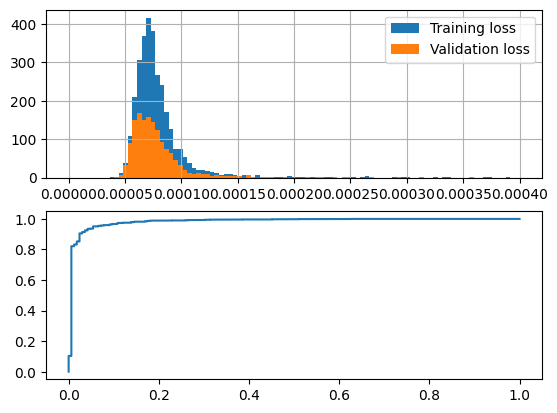

In [ ]:
from scipy import stats
from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance

#Loss sketch + AUC
def check_similarity_anderson(data1, data2):
    # Thực hiện kiểm định Anderson-Darling cho 2 mẫu
    result = stats.anderson_ksamp([data1, data2])
    
    print(f"Anderson-Darling statistic: {result.statistic:.4f}")
    
    # Các ngưỡng giá trị tới hạn (Critical values) tương ứng với các mức ý nghĩa
    # [25%, 10%, 5%, 2.5%, 1%, 0.5%, 0.1%]
    critical_values = result.critical_values
    sig_levels = [25, 10, 5, 2.5, 1, 0.5, 0.1]
    
    print("-" * 30)
    print("Mức ý nghĩa (%) | Giá trị tới hạn")
    for lvl, cv in zip(sig_levels, critical_values):
        print(f"{lvl:14}% | {cv:.4f}")
    print("-" * 30)

    # Giải thích kết quả
    # Nếu statistic < critical_value ở mức 1% (0.01), ta KHÔNG bác bỏ giả thuyết H0
    # Nghĩa là 2 phân phối GIỐNG NHAU với độ tin cậy 99%
    alpha_1_percent_cv = critical_values[4] 
    
    if result.statistic < alpha_1_percent_cv:
        print("Kết luận: Hai phân phối GIỐNG NHAU (Độ tin cậy 99%)")
    else:
        print("Kết luận: Hai phân phối CÓ SỰ KHÁC BIỆT (Độ tin cậy 99%)")

    return result

fig,ax = plt.subplots(2,1)
ax.flatten()

file = os.path.join(BACK_UP,"loss.json")
with open(file, "r") as f:
    loss = json.load(f)
    train = np.array(loss["train"])
    val = np.array(loss["val"])
    stat, p = ks_2samp(train, val)

    print("KS statistic:", stat)
    print("p-value:", p)

    wd = wasserstein_distance(train, val)

    print("Wasserstein Distance:", wd)

    result = check_similarity_anderson(train, val)
    print(result)

    ax[0].hist(train, bins = np.linspace(0, 0.0004, 100), label = "Training loss")
    ax[0].hist(val, bins = np.linspace(0, 0.0004, 100), label = "Validation loss")

    ax[0].legend()
    ax[0].grid()

file = os.path.join(BACK_UP,"auc.json")
with open(file, "r") as f:
    auc = json.load(f)
    fpr = np.array(auc["fpr"])
    tpr = np.array(auc["tpr"])
    ax[1].plot(fpr,tpr)

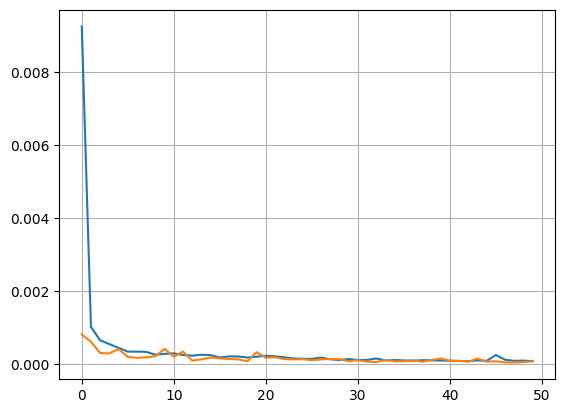

In [ ]:
#Training process
file = os.path.join(BACK_UP,"epoch.json")
with open(file, "r") as f:
    epoch = json.load(f)
    train = np.array(epoch["train"])
    val = np.array(epoch["val"])
    x = np.array(range(len(train)))
    plt.plot(x,train,label="Training loss")
    plt.plot(x,val,label="Validation loss")
    plt.grid()
    plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_12496\1077462457.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


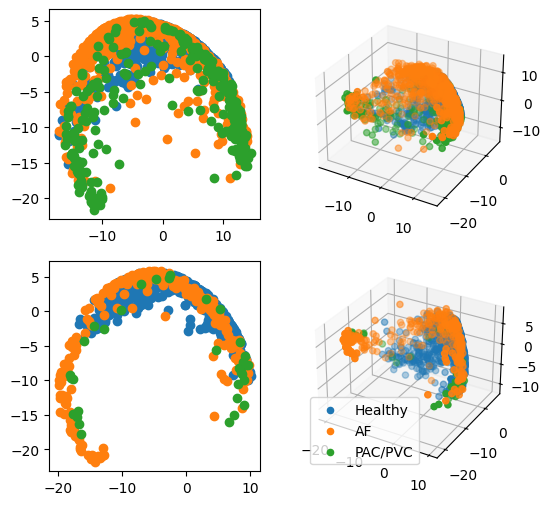

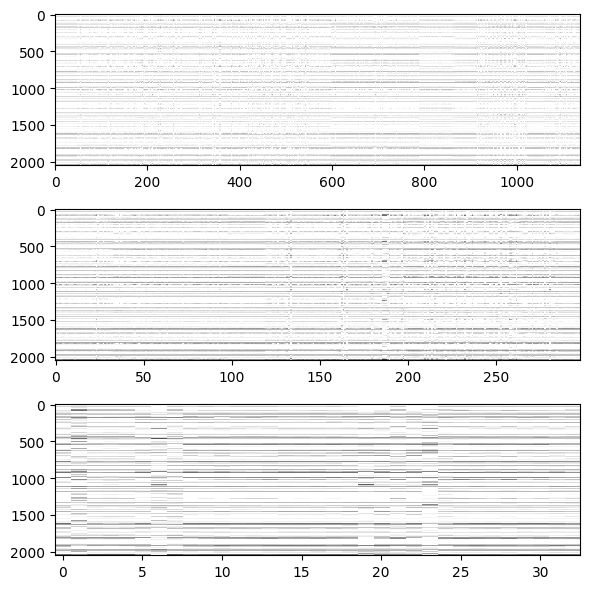

In [28]:
#PCA case
file1 = os.path.join(BACK_UP,"test_latent.json")
file2 = os.path.join(BACK_UP,"val_latent.json")

fig = plt.figure(figsize=(6, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4, projection='3d')

with open(file1, "r") as f:
    data = json.load(f)
    latent_np = data["latent_np"]
    latent = np.array(data["latent"])
    idx0 = np.where(np.array(data["disease"]) == 0)[0]
    idx1 = np.where(np.array(data["disease"]) == 1)[0]
    idx2 = np.where(np.array(data["disease"]) > 1)[0]
    ax1.scatter(latent[idx0, 0], latent[idx0, 1], label = "Healthy")
    ax1.scatter(latent[idx1, 0], latent[idx1, 1], label = "AF")
    ax1.scatter(latent[idx2, 0], latent[idx2, 1], label = "PAC/PVC")
    ax2.scatter(latent[idx0, 0], latent[idx0, 1], latent[idx0, 2], label = "Healthy")
    ax2.scatter(latent[idx1, 0], latent[idx1, 1], latent[idx1, 2], label = "AF")
    ax2.scatter(latent[idx2, 0], latent[idx2, 1], latent[idx2, 2], label = "PAC/PVC")
plt.legend()

with open(file2, "r") as f:
    data = json.load(f)
    latent = np.array(data["latent"])
    idx0 = np.where(np.array(data["disease"]) == 0)[0]
    idx1 = np.where(np.array(data["disease"]) == 1)[0]
    idx2 = np.where(np.array(data["disease"]) > 1)[0]
    ax3.scatter(latent[idx0, 0], latent[idx0, 1], label = "Healthy")
    ax3.scatter(latent[idx1, 0], latent[idx1, 1], label = "AF")
    ax3.scatter(latent[idx2, 0], latent[idx2, 1], label = "PAC/PVC")
    ax4.scatter(latent[idx0, 0], latent[idx0, 1], latent[idx0, 2], label = "Healthy")
    ax4.scatter(latent[idx1, 0], latent[idx1, 1], latent[idx1, 2], label = "AF")
    ax4.scatter(latent[idx2, 0], latent[idx2, 1], latent[idx2, 2], label = "PAC/PVC")

plt.legend()
plt.show()

latent_np = np.array(latent_np)
latent = (latent_np - latent_np.min()) / (latent_np.max() - latent_np.min() + 1e-8)
sketch = np.transpose(latent)
fig, ax = plt.subplots(3,1,figsize=(6,6))
ax[0].imshow(sketch[:,idx0],aspect='auto',cmap='gray_r',interpolation='nearest')
ax[1].imshow(sketch[:,idx1],aspect='auto',cmap='gray_r',interpolation='nearest')
ax[2].imshow(sketch[:,idx2],aspect='auto',cmap='gray_r',interpolation='nearest')
plt.tight_layout()
plt.show()

In [31]:
#Inference
file = os.path.join(BACK_UP,"depict.json")
with open(file2, "r") as f:
    data = json.load(f)
    # lab = data["label"]
    ppg = data["ppg"]
    adjust = data["adjust"]

plt.plot(ppg[0])

KeyError: 'ppg'